In [829]:
# 修改工作路径
import os
os.chdir('D:/0_PhdData/0_Paper/4_Global_P/4.2_Global_P_Calculation/') # 修改工作路径

In [859]:
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import scipy.stats as stats

In [860]:
df_clean=pd.read_csv('./9_Major_revision/0_New_Data/Meta_New/P_loss_clean.csv')
df_clean

,Num_meta,References,PRE,TMP,PET,BULK,CLAY,SILT,SAND,SOC,...,Nfer,Kfer,Crop,Ploss,Class_fill,X,Y,Country,Region,cooks_d
0,1,不同耕作方式与秸秆还田对稻田氮磷养分径流流失的影响,1260.910034,16.684601,981.510986,1.74825,22.988001,36.679501,40.332500,15.719258,...,1,1,Rice,0.50,Fill,119.331864,31.450193,中国,China,2.082318e-08
1,2,不同耕作方式与秸秆还田对稻田氮磷养分径流流失的影响,1260.910034,16.684601,981.510986,1.74825,22.988001,36.679501,40.332500,15.719258,...,1,1,Rice,0.63,Fill,119.331864,31.450193,中国,China,1.157847e-08
2,3,不同耕作方式与秸秆还田对稻田氮磷养分径流流失的影响,1260.910034,16.684601,981.510986,1.74825,22.988001,36.679501,40.332500,15.719258,...,1,1,Rice,0.78,Fill,119.331864,31.450193,中国,China,4.258626e-09
3,4,不同耕作方式与秸秆还田对稻田氮磷养分径流流失的影响,1260.910034,16.684601,981.510986,1.74825,22.988001,36.679501,40.332500,15.719258,...,1,1,Rice,0.39,Fill,119.331864,31.450193,中国,China,3.074955e-08
4,5,不同耕作方式与秸秆还田对稻田氮磷养分径流流失的影响,1260.910034,16.684601,981.510986,1.74825,22.988001,36.679501,40.332500,15.719258,...,1,1,Rice,0.51,Fill,119.331864,31.450193,中国,China,2.001642e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,1230,地表管理与施肥方式对太湖流域旱地磷素流失的影响,1221.700000,16.728500,978.695984,1.71932,21.008600,39.510201,39.481098,15.440500,...,1,1,Others,0.38,Meta,119.428472,31.255972,中国,China,2.830088e-08
5373,693,有机无机肥配施对旱地作物养分利用率及氮磷流失的影响,1381.670044,18.385599,971.098999,1.74879,22.919300,39.600899,37.479801,12.842227,...,1,1,Others,14.00,Meta,112.852880,28.732027,中国,China,1.544531e-06
5374,4323,Varying Influence of Dairy Manure Injection on...,874.500000,9.000000,919.028992,1.73321,22.574100,46.000000,31.425900,18.938500,...,1,1,Maize,0.11,Fill,-77.950035,40.709923,USA,North America,3.139820e-07
5375,765,自然降雨条件下减肥和资源再利用对东北黑土玉米地氮磷流失的影响,568.500000,4.800000,923.299011,1.78495,25.481300,41.045700,33.473099,17.151972,...,1,1,Maize,0.18,Meta,125.357651,43.848264,中国,China,7.063907e-08


# 建模

In [861]:
order_name = ['OP','PRE','TMP','PET','SOC','pH','BULK','CEC','CLAY','SILT','SAND','SLOPE','IRR','Pfer','Nfer','Kfer','Crop','Ploss']
data = df_clean[order_name]

data_one_hot = pd.get_dummies(data, columns=['Crop'],dtype=int) # 确保 Ploss 放在最后 
columns = [col for col in data_one_hot.columns if col != 'Ploss'] + ['Ploss'] 
data = data_one_hot[columns]
data

,OP,PRE,TMP,PET,SOC,pH,BULK,CEC,CLAY,SILT,...,SLOPE,IRR,Pfer,Nfer,Kfer,Crop_Maize,Crop_Others,Crop_Rice,Crop_Wheat,Ploss
0,27.343843,1260.910034,16.684601,981.510986,15.719258,6.18370,1.74825,14.0102,22.988001,36.679501,...,0.403939,1,1.000,1,1,0,0,1,0,0.50
1,27.343843,1260.910034,16.684601,981.510986,15.719258,6.18370,1.74825,14.0102,22.988001,36.679501,...,0.403939,1,1.000,1,1,0,0,1,0,0.63
2,27.343843,1260.910034,16.684601,981.510986,15.719258,6.18370,1.74825,14.0102,22.988001,36.679501,...,0.403939,1,1.000,1,1,0,0,1,0,0.78
3,27.343843,1260.910034,16.684601,981.510986,15.719258,6.18370,1.74825,14.0102,22.988001,36.679501,...,0.403939,1,1.000,1,1,0,0,1,0,0.39
4,27.343843,1260.910034,16.684601,981.510986,15.719258,6.18370,1.74825,14.0102,22.988001,36.679501,...,0.403939,1,1.000,1,1,0,0,1,0,0.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,11.730000,1221.700000,16.728500,978.695984,15.440500,5.62000,1.71932,14.0790,21.008600,39.510201,...,2.782480,0,1.000,1,1,0,1,0,0,0.38
5373,27.310000,1381.670044,18.385599,971.098999,12.842227,5.96000,1.74879,16.0403,22.919300,39.600899,...,0.108400,0,1.000,1,1,0,1,0,0,14.00
5374,53.057858,874.500000,9.000000,919.028992,18.938500,5.84405,1.73321,13.8664,22.574100,46.000000,...,10.750000,0,1.000,1,1,1,0,0,0,0.11
5375,43.200000,568.500000,4.800000,923.299011,17.151972,6.63000,1.78495,18.2328,25.481300,41.045700,...,0.479515,0,0.675,1,1,1,0,0,0,0.18


In [862]:
data.isna().any(axis=1).sum()

0

清洗数据

In [863]:
# 基础包
import pandas as pd
import numpy as np
# 绘图的包
import matplotlib.pyplot as plt

import matplotlib as mpl
# PINNs的包
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [864]:
# 1. 检查CUDA可用性
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


1. 特征值处理

In [865]:
# 对训练集和测试集进行归一化
def custom_normalize(data, data_min, data_max):
    return (data - data_min) / (data_max - data_min + 1e-8)  # 加上一个小的数值防止除以零

def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [866]:
# 定义需要归一化的特征
features_to_normalize = ['OP', 'PRE', 'TMP', 'PET', 'SOC', 'pH', 'BULK', 'CEC',
                         'CLAY', 'SILT', 'SAND', 'SLOPE', 'Pfer']

# 提取特征和目标变量
all_features = ['OP', 'PRE', 'TMP', 'PET', 'SOC', 'pH', 'BULK', 'CEC',
                'CLAY', 'SILT', 'SAND', 'SLOPE', 'IRR', 'Pfer', 'Nfer', 'Kfer','Crop_Maize','Crop_Others','Crop_Rice','Crop_Wheat']
X = data[all_features].values  # 特征数据
Y = data['Ploss'].values.reshape(-1, 1)  # 目标数据

# 将数据转换为 PyTorch 张量
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

In [867]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,27.343843,1260.910034,16.684601,981.510986,15.719257,6.18370,1.74825,14.0102,22.988001,36.679501,40.332500,0.403939,1.0,1.000,1.0,1.0,0.0,0.0,1.0,0.0
1,27.343843,1260.910034,16.684601,981.510986,15.719257,6.18370,1.74825,14.0102,22.988001,36.679501,40.332500,0.403939,1.0,1.000,1.0,1.0,0.0,0.0,1.0,0.0
2,27.343843,1260.910034,16.684601,981.510986,15.719257,6.18370,1.74825,14.0102,22.988001,36.679501,40.332500,0.403939,1.0,1.000,1.0,1.0,0.0,0.0,1.0,0.0
3,27.343843,1260.910034,16.684601,981.510986,15.719257,6.18370,1.74825,14.0102,22.988001,36.679501,40.332500,0.403939,1.0,1.000,1.0,1.0,0.0,0.0,1.0,0.0
4,27.343843,1260.910034,16.684601,981.510986,15.719257,6.18370,1.74825,14.0102,22.988001,36.679501,40.332500,0.403939,1.0,1.000,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,11.730000,1221.699951,16.728500,978.695984,15.440500,5.62000,1.71932,14.0790,21.008600,39.510201,39.481098,2.782480,0.0,1.000,1.0,1.0,0.0,1.0,0.0,0.0
5373,27.309999,1381.670044,18.385599,971.098999,12.842227,5.96000,1.74879,16.0403,22.919300,39.600899,37.479801,0.108400,0.0,1.000,1.0,1.0,0.0,1.0,0.0,0.0
5374,53.057858,874.500000,9.000000,919.028992,18.938499,5.84405,1.73321,13.8664,22.574100,46.000000,31.425900,10.750000,0.0,1.000,1.0,1.0,1.0,0.0,0.0,0.0
5375,43.200001,568.500000,4.800000,923.299011,17.151972,6.63000,1.78495,18.2328,25.481300,41.045700,33.473099,0.479515,0.0,0.675,1.0,1.0,1.0,0.0,0.0,0.0


In [868]:
# 划分数据集，测试集占20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=56)

In [869]:
# 获取需要归一化的列索引
normalize_indices = [all_features.index(f) for f in features_to_normalize]

In [870]:
# 计算训练集中需要归一化列的最小值和最大值
X_train_to_normalize = X_train[:, normalize_indices]
X_min = X_train_to_normalize.min(dim=0, keepdim=True)[0]
X_max = X_train_to_normalize.max(dim=0, keepdim=True)[0]

# 创建一个拷贝以存放归一化后的训练集和测试集
X_train_normalized = X_train.clone()
X_test_normalized = X_test.clone()

In [871]:
# 对需要归一化的列进行归一化
X_train_normalized[:, normalize_indices] = custom_normalize(X_train_to_normalize, X_min, X_max)
X_test_normalized[:, normalize_indices] = custom_normalize(X_test[:, normalize_indices], X_min, X_max)

X_param_normalized = X_train_normalized[:,1:20] #参数网络，排除OP
print('训练数据：',X_param_normalized.shape)
print('参数数据：',X_train_normalized.shape)

训练数据： torch.Size([4301, 19])
参数数据： torch.Size([4301, 20])


In [872]:
# 对目标变量归一化
Y_min = Y_train.min()
Y_max = Y_train.max()
Y_train_normalized = custom_normalize(Y_train, Y_min, Y_max)
Y_test_normalized = custom_normalize(Y_test, Y_min, Y_max)

In [873]:
# 转换为需要梯度的张量并移动到设备上
X_param = X_param_normalized.to(device)

data_x_train = X_train_normalized.requires_grad_(True).to(device)
data_y_train = Y_train_normalized.to(device)

data_x_test = X_test_normalized.to(device)
data_y_test = Y_test_normalized.to(device)

# 检查 requires_grad 属性
print("data_x_train requires_grad:", data_x_train.requires_grad)  # 应为 True
print("data_y_train requires_grad:", data_y_train.requires_grad)  # 应为 False
print("data_x_test requires_grad:", data_x_test.requires_grad)    # 应为 False

# 检查张量设备
print("data_x_train device:", data_x_train.device)  # 应与 device 一致
print("data_y_train device:", data_y_train.device)  # 应与 device 一致
print("data_x_test device:", data_x_test.device)    # 应与 device 一致

data_x_train requires_grad: True
data_y_train requires_grad: False
data_x_test requires_grad: False
data_x_train device: cuda:0
data_y_train device: cuda:0
data_x_test device: cuda:0


In [874]:
# ===== 构造 OP collocation points（步长=5）=====
op_grid = torch.arange(0, 101, 5, device=device).float()   # 0,5,...,100  共21个点
op_grid_norm = custom_normalize(op_grid, X_min[:, 0].to(device), X_max[:, 0].to(device))

n_train = data_x_train.shape[0]
n_op = op_grid_norm.shape[0]

# 把每个训练样本复制 n_op 份，并把第0列(OP)替换为 op_grid_norm
x_colloc = data_x_train.detach().clone()   # 先不带图
x_colloc = x_colloc.repeat_interleave(n_op, dim=0)  # [n_train*n_op, 16]
x_colloc[:, 0] = op_grid_norm.repeat(n_train)       # 每个样本对应一条OP曲线

x_colloc = x_colloc.requires_grad_(True)            # 关键：要对OP求导
x_param_colloc = x_colloc[:, 1:20]                  # param net输入(不含OP)

2. 构建网络

In [875]:
import random
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 尽量使用确定性算法（⚠️ 有些算子会报错）
    torch.use_deterministic_algorithms(False)

set_seed(7)

In [876]:
# 主网络：用于预测
class YieldPredictionModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(YieldPredictionModel, self).__init__()
        layers = []
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.Tanh())
            input_size = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# 子网络：动态生成 a, b, c 参数
class ParameterNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=3):
        super(ParameterNetwork, self).__init__()
        layers = []
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.Tanh())
            input_size = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)
        

    def forward(self, x):
        return self.network(x)

In [877]:
# 实例化模型并移动到设备上
# YieldPredictionModel 输入特征包括 OP 和其他特征，共22个特征
yield_model = YieldPredictionModel(input_size=20, hidden_sizes=[16, 16, 16], output_size=1).to(device)

# ParameterNetwork 输入特征不包括 OP 和 'IRR', 'Pfer', 'Nfer', 'Kfer'，共15个特征
# PRE, TMP, PET, SOC, pH, BULK, CLAY, SILT, SAND, SLOPE
param_model = ParameterNetwork(input_size=19, hidden_sizes=[50]).to(device)

# 定义优化器，将主网络和参数网络的参数一起优化
optimizer = torch.optim.Adam(
    [
        {"params": yield_model.parameters(), "lr": 0.01},
        {"params": param_model.parameters(), "lr": 0.0001},  # 甚至 1e-5
    ]
)

In [ ]:
def pinn_loss_with_boundary(
    y_pred_obs, y_true_obs,
    data_x_obs,              # 原训练观测点（用于数据loss）
    x_colloc, x_param_colloc,# 新增：OP梯度配点（用于物理loss）
    epoch, epochs
):
    # ========= 数据误差（观测点）=========
    mse_loss_data = nn.MSELoss()(y_pred_obs, y_true_obs)

    # ========= 物理误差（collocation点：沿OP=0..100）=========
    y_pred_col = yield_model(x_colloc)
    abc_col = param_model(x_param_colloc)

    b = abc_col[:, 1]
    c = abc_col[:, 2]

    dy_dop = torch.autograd.grad(
        y_pred_col, x_colloc,
        grad_outputs=torch.ones_like(y_pred_col),
        create_graph=True
    )[0][:, 0]  # 对第0列OP求导
    k = 10
    # 你的目标微分形式（按你原来的写法）
    phys_target = 10 * b * (c * torch.exp(c * k * x_colloc[:, 0]))
    diff_loss = torch.mean((dy_dop - phys_target) ** 2)

    # ========= 正则（collocation点上也可以约束）=========
    l2_reg_c = torch.norm(torch.relu(c - 2), 2) + torch.norm(torch.relu(1 - c), 2)
    l2_reg_b = torch.norm(torch.relu(b - 1), 2) + torch.norm(torch.relu(0 - b), 2)
    reg_loss = l2_reg_b + l2_reg_c

    # ========= 权重（你原来的）=========
    lambda_data = 100
    lambda_diff =10 * min(epoch / (0.5 * epochs), 500.0)
    lambda_reg = 0.3

    total = lambda_data*mse_loss_data + lambda_diff*diff_loss + lambda_reg*reg_loss

    return total, lambda_data*mse_loss_data, lambda_diff*diff_loss, lambda_reg*reg_loss, a.mean(), b.mean(), c.mean()

In [879]:
# 切换到训练模式
yield_model.train()
param_model.train()
print("Model is now in training mode.")

Model is now in training mode.


In [1]:
loss_history = []
epochs = 14000

for epoch in range(epochs):
    optimizer.zero_grad()

    # 观测点预测（数据loss）
    y_pred_train_obs = yield_model(data_x_train)

    # collocation点在每个epoch构造也行；如果你放在epoch外面，这里就不用重复建
    # 建议：如果显存顶不住，就每次随机抽一部分训练样本做collocation
    # 这里先用“全量训练样本 × 21个OP点”的版本

    loss, data_loss, diff_loss, reg_loss, a, b, c = pinn_loss_with_boundary(
        y_pred_train_obs, data_y_train,
        data_x_train,
        x_colloc, x_param_colloc,
        epoch, epochs
    )

    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Total={loss.item():.4f} Data={data_loss.item():.4f} Diff={diff_loss.item():.4f} Reg={reg_loss.item():.4f}")

NameError: name 'optimizer' is not defined

In [882]:
# 开始模型评估模式
yield_model.eval()
param_model.eval()
print("Model is now in evaluation mode.")

Model is now in evaluation mode.


3. 效果评估

In [883]:
# 在测试集洱和训练集上进行预测
with torch.no_grad():
    y_pred_test = yield_model(data_x_test)

with torch.no_grad():
    y_pred_train = yield_model(data_x_train)

In [884]:
# 将预测值和真实值反归一化
y_pred_test_denormalized = custom_denormalize(y_pred_test, Y_min, Y_max)
y_test_denormalized = custom_denormalize(data_y_test, Y_min, Y_max)

y_pred_train_denormalized = custom_denormalize(y_pred_train, Y_min, Y_max)
y_train_denormalized = custom_denormalize(data_y_train, Y_min, Y_max)

# 将数据从 PyTorch 张量转换为 NumPy 数组a
y_pred_test_np = y_pred_test_denormalized.cpu().numpy()
y_test_np = y_test_denormalized.cpu().numpy()

# 将数据从 PyTorch 张量转换为 NumPy 数组
y_pred_train_np = y_pred_train_denormalized.cpu().numpy()
y_train_np = y_train_denormalized.cpu().numpy()

# 计算 R2
r2_test = r2_score(y_test_np, y_pred_test_np)
r2_train = r2_score(y_train_np, y_pred_train_np)
print(f'R2 on test set: {r2_test:.4f}')
print(f'R2 on train set: {r2_train:.4f}')

R2 on test set: 0.7718
R2 on train set: 0.8750


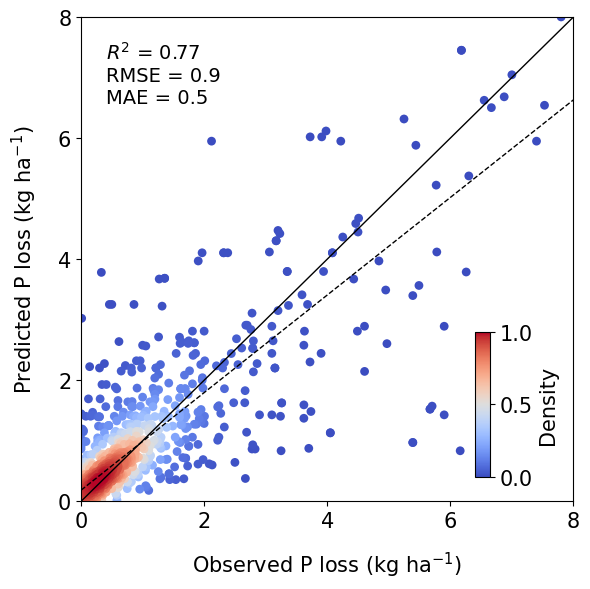

In [905]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

x_obs = np.asarray(y_test_np).ravel()
y_pre = np.asarray(y_pred_test_np).ravel()

mask = np.isfinite(x_obs) & np.isfinite(y_pre)
x_obs = x_obs[mask]
y_pre = y_pre[mask]

# ===== KDE 密度 =====
xy = np.vstack([x_obs, y_pre])
z = gaussian_kde(xy)(xy)

# ===== 归一化到 0–1 =====
z = (z - z.min()) / (z.max() - z.min())

# 高密度点后画
idx = z.argsort()
x_obs, y_pre, z = x_obs[idx], y_pre[idx], z[idx]

plt.figure(figsize=(6, 6))

sc = plt.scatter(x_obs, y_pre, c=z, s=40, cmap='coolwarm', vmin=0, vmax=1, edgecolors='none')

# ===== colorbar =====
ax = plt.gca()
cax = ax.inset_axes([0.8, 0.05, 0.03, 0.3])  # [左, 下, 宽, 高]
cbar = plt.colorbar(sc, cax=cax,fraction=0.1, pad=0.05, aspect=20)
cbar.set_label('Density', fontsize=15)
cbar.set_ticks([0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=15)

# ===== 1:1 线 =====
plt.plot([0, 8], [0, 8], color='black', linewidth=1)

# ===== 拟合线 =====
coef = np.polyfit(x_obs, y_pre, 1)
fit_line = np.poly1d(coef)
x_fit = np.linspace(0, 8, 200)
plt.plot(x_fit, fit_line(x_fit), linestyle='--', color='black', linewidth=1)

# ===== 指标文本（左上角）=====
R2 = r2_score(x_obs, y_pre)
RMSE = np.sqrt(mean_squared_error(x_obs, y_pre))
MAE = mean_absolute_error(x_obs, y_pre)

plt.text(0.05, 0.95, f'$R^2$ = {R2:.2f}\nRMSE = {RMSE:.1f}\nMAE = {MAE:.1f}',
    transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

# ===== 坐标轴 =====
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.xticks(range(0, 9, 2), fontsize=15)
plt.yticks(range(0, 9, 2), fontsize=15)
plt.xlabel('Observed P loss (kg ha$^{-1}$)', fontsize=15, labelpad=13.5)
plt.ylabel('Predicted P loss (kg ha$^{-1}$)', fontsize=15, labelpad=13.5)

plt.tight_layout()
plt.show()